# Training Final — Fine-Tuning IndoBERT (JKT48, 3 kelas)

Perbaikan dari `Training_final_IndoBERT.ipynb` versi lama (2 pelanggaran metodologis fatal):

1. **Dulu:** `eval_dataset=test_dataset` dipakai LANGSUNG di `Trainer` selama training
   (`eval_strategy="epoch"`, `load_best_model_at_end=True`, `EarlyStoppingCallback`) — artinya
   checkpoint terbaik & keputusan early-stopping ditentukan dari performa di test set.
   **Sekarang:** `eval_dataset=validation_dataset`. Test set hanya disentuh SATU KALI di akhir,
   sebagai evaluasi final, dan `trainer.predict()` untuk test tidak pernah dipanggil sebelum
   training selesai total.
2. **Dulu:** `metric_for_best_model="f1"` pakai `average="weighted"`. Untuk 3 kelas dengan
   distribusi tidak seimbang (lihat `data_final/`), ini bisa menyembunyikan performa buruk
   di kelas minoritas (Netral). **Sekarang:** pemilihan checkpoint pakai **Macro F1** dari
   validation set.
3. Tidak ada train/val/test split terpisah di versi lama (cuma train/test 80:20).
   **Sekarang:** dataset dibaca langsung dari `data_final/train.csv`, `validation.csv`,
   `test.csv` yang sudah displit stratified & sudah dicek bebas exact-duplicate antar split
   (lihat laporan `laporan/audit_dataset.txt`).

Notebook ini BELUM saya jalankan sungguhan (butuh GPU + `torch`/`transformers`, tidak tersedia
di sandbox saya). Struktur & konfigurasinya sudah benar secara logika, tapi jalankan di Colab
dan periksa error runtime seperti biasa.


In [1]:
import torch
print("CUDA tersedia:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Nama GPU:", torch.cuda.get_device_name(0))
else:
    print("Tidak ada GPU terdeteksi oleh PyTorch")

CUDA tersedia: True
Nama GPU: Tesla T4


In [2]:
!pip install -q transformers datasets torch scikit-learn accelerate

import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

RANDOM_STATE = 42
MODEL_NAME = "indobenchmark/indobert-base-p1"  # ganti sesuai varian IndoBERT yang dipakai


In [3]:
# 1. Load dataset final (SUDAH displit stratified + dicek bebas leakage sebelumnya)
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("validation.csv")
test_df = pd.read_csv("test.csv")

label2id = {"Negatif": 0, "Netral": 1, "Positif": 2}
id2label = {v: k for k, v in label2id.items()}

for name, d in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(f"{name:<12} n={len(d):<6} dist={d['label'].value_counts().to_dict()}")

train_df["label_id"] = train_df["label"].map(label2id)
val_df["label_id"] = val_df["label"].map(label2id)
test_df["label_id"] = test_df["label"].map(label2id)

assert train_df["label_id"].isna().sum() == 0, "ada label di luar 3 kelas di train!"
assert val_df["label_id"].isna().sum() == 0, "ada label di luar 3 kelas di validation!"
assert test_df["label_id"].isna().sum() == 0, "ada label di luar 3 kelas di test!"


train        n=16019  dist={'Positif': 9832, 'Negatif': 5457, 'Netral': 730}
validation   n=3433   dist={'Positif': 2107, 'Negatif': 1169, 'Netral': 157}
test         n=3433   dist={'Positif': 2107, 'Negatif': 1170, 'Netral': 156}


In [4]:
# 2. VALIDASI ULANG: pastikan tidak ada leakage sebelum training dimulai
train_set = set(train_df["komentar_bersih"])
val_set = set(val_df["komentar_bersih"])
test_set = set(test_df["komentar_bersih"])

print("Exact duplicate train-val :", len(train_set & val_set))
print("Exact duplicate train-test:", len(train_set & test_set))
print("Exact duplicate val-test  :", len(val_set & test_set))

assert len(train_set & test_set) == 0, "DATA LEAKAGE terdeteksi antara train dan test!"
assert len(train_set & val_set) == 0, "DATA LEAKAGE terdeteksi antara train dan validation!"
assert len(val_set & test_set) == 0, "DATA LEAKAGE terdeteksi antara validation dan test!"
print("\nAMAN — tidak ada exact duplicate antar split.")


Exact duplicate train-val : 0
Exact duplicate train-test: 0
Exact duplicate val-test  : 0

AMAN — tidak ada exact duplicate antar split.


In [5]:
# 3. Tokenizer IndoBERT (terpisah dari preprocessing teks yang sudah dilakukan sebelumnya)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_hf_dataset(df):
    ds = Dataset.from_pandas(df[["komentar_bersih", "label_id"]].rename(columns={"label_id": "labels"}))
    return ds.map(lambda x: tokenizer(x["komentar_bersih"], truncation=True, padding="max_length", max_length=128), batched=True)

train_ds = to_hf_dataset(train_df)
val_ds = to_hf_dataset(val_df)
test_ds = to_hf_dataset(test_df)


Map:   0%|          | 0/16019 [00:00<?, ? examples/s]

Map:   0%|          | 0/3433 [00:00<?, ? examples/s]

Map:   0%|          | 0/3433 [00:00<?, ? examples/s]

In [6]:
# 4. Class weighting DARI TRAIN SAJA (tidak bocor ke val/test)
from sklearn.utils.class_weight import compute_class_weight

classes = np.array(sorted(label2id.values()))
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_df["label_id"].values)
class_weights = torch.tensor(weights, dtype=torch.float)
print("Class weights (Negatif, Netral, Positif):", class_weights.tolist())


Class weights (Negatif, Netral, Positif): [0.9784985780715942, 7.314611911773682, 0.5430905818939209]


In [7]:
# 5. Load model IndoBERT dengan mapping label eksplisit
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [8]:
# 6. Metrik evaluasi — Macro F1 dipakai untuk pemilihan checkpoint (bukan weighted F1)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    _, _, f1_weighted, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }


In [9]:
# 7. Konfigurasi training — eval_dataset = VALIDATION, bukan test
training_args = TrainingArguments(
    output_dir="hasil_model/checkpoints",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",   # <- diperbaiki, dulu "f1" (weighted)
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=2,
    seed=RANDOM_STATE,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,              # <- diperbaiki, dulu test_ds
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
1,0.752802,0.849367,0.870667,0.833827,0.626121,0.629548,0.855530
2,0.548060,0.761079,0.877075,0.714548,0.700090,0.704054,0.874886
3,0.496828,0.863781,0.867463,0.693031,0.746780,0.710291,0.877685
4,0.275281,1.127105,0.878241,0.707087,0.746734,0.721600,0.884938
5,0.167835,1.310938,0.889310,0.723232,0.733731,0.728176,0.890706


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5010, training_loss=0.4506420373916626, metrics={'train_runtime': 2061.0592, 'train_samples_per_second': 38.861, 'train_steps_per_second': 2.431, 'total_flos': 5268517298231040.0, 'train_loss': 0.4506420373916626, 'epoch': 5.0})

## Evaluasi akhir di TEST SET

Baru dipanggil di sini, SATU KALI, setelah training & pemilihan checkpoint selesai total
berdasarkan validation set. Tidak ada keputusan model apa pun yang dibuat berdasarkan hasil
sel ini — angka di bawah adalah laporan akhir, bukan sinyal untuk tuning ulang.


In [10]:
test_results = trainer.predict(test_ds)
test_preds = np.argmax(test_results.predictions, axis=-1)
test_labels = test_results.label_ids

print("=== HASIL EVALUASI TEST SET (FINAL, SATU KALI) ===")
print("Accuracy       :", accuracy_score(test_labels, test_preds))
print()
print("Classification Report:")
print(classification_report(test_labels, test_preds, target_names=[id2label[i] for i in range(3)], zero_division=0))
print()
print("Confusion Matrix:")
print(confusion_matrix(test_labels, test_preds))


=== HASIL EVALUASI TEST SET (FINAL, SATU KALI) ===
Accuracy       : 0.8814448004660647

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.87      0.88      0.88      1170
      Netral       0.34      0.37      0.35       156
     Positif       0.93      0.92      0.93      2107

    accuracy                           0.88      3433
   macro avg       0.71      0.72      0.72      3433
weighted avg       0.88      0.88      0.88      3433


Confusion Matrix:
[[1033   54   83]
 [  44   57   55]
 [ 112   59 1936]]


### Visualisasi Confusion Matrix


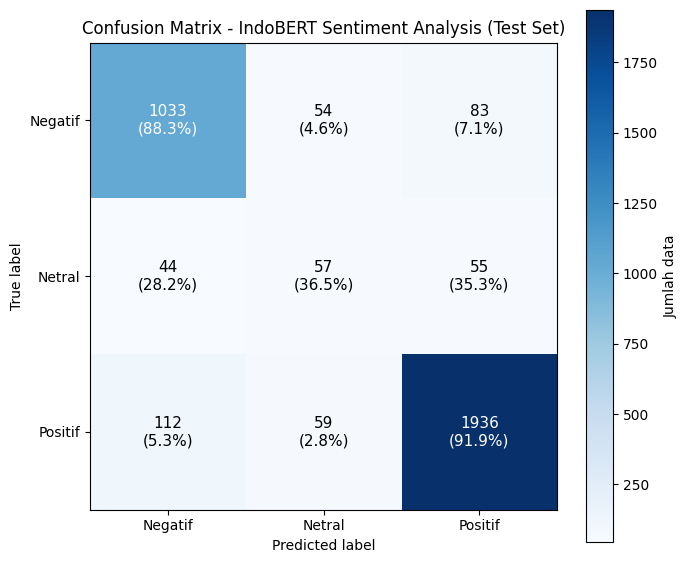

Total data test: 3,433 baris
  Negatif : 1,170 data (recall: 88.3%)
  Netral  : 156 data (recall: 36.5%)
  Positif : 2,107 data (recall: 91.9%)


In [14]:
import numpy as np
import matplotlib.pyplot as plt

target_names = [id2label[i] for i in range(3)]
cm = confusion_matrix(test_labels, test_preds)
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

# Anotasi: angka asli + persentase per baris, supaya jelas proporsinya
# walau jumlah data tiap kelas berbeda-beda.
annot = np.array([
    [f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(len(target_names)))
ax.set_yticks(range(len(target_names)))
ax.set_xticklabels(target_names)
ax.set_yticklabels(target_names)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix - IndoBERT Sentiment Analysis (Test Set)")

# warna teks otomatis putih di sel gelap, hitam di sel terang
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, annot[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=11
        )

plt.colorbar(im, ax=ax, label="Jumlah data")
plt.tight_layout()
plt.show()

print(f"Total data test: {cm.sum():,} baris")
for i, nama in enumerate(target_names):
    print(f"  {nama:8s}: {cm[i].sum():,} data (recall: {cm[i,i]/cm[i].sum()*100:.1f}%)")

### WordCloud per Kelas Sentimen (Test Set)


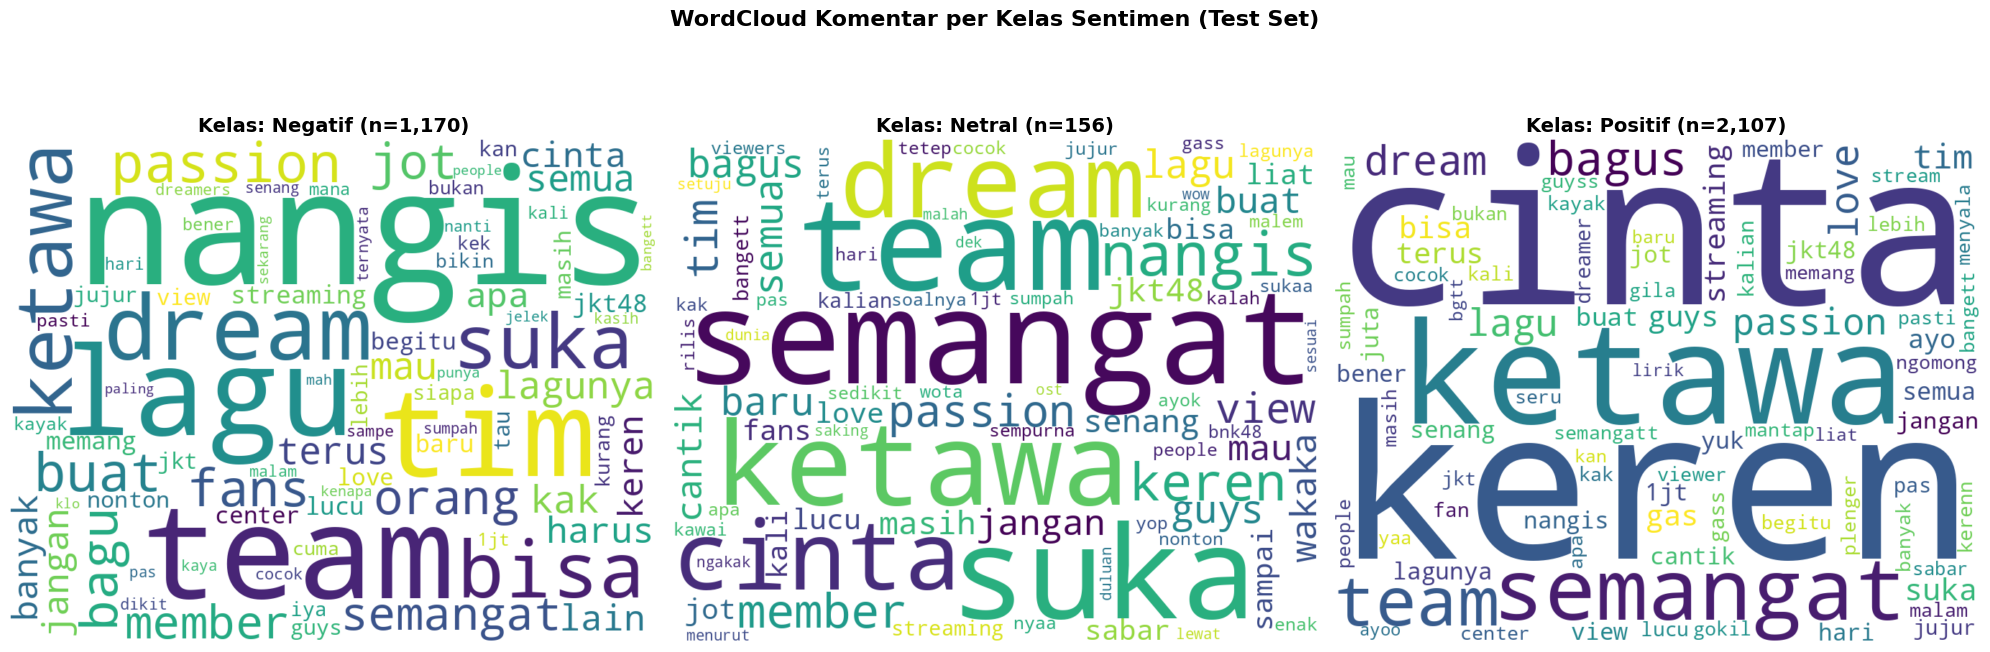

In [16]:
!pip install -q wordcloud

import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud

try:
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
    stopwords_id = set(StopWordRemoverFactory().get_stop_words())
except ImportError:
    stopwords_id = set()

stopwords_id |= {
    "yang", "dan", "di", "ke", "dari", "untuk", "dengan", "ini", "itu",
    "juga", "ada", "aja", "nya", "ya", "ga", "gak", "gk", "sih", "banget",
    "bgt", "deh", "kok", "dong", "nih", "udah", "dah", "saya", "aku",
    "kamu", "kita", "kami", "mereka", "dia", "lagi", "tapi", "kalau",
    "jadi", "dulu", "atau", "karena", "pada", "oleh", "akan", "sudah",
    "belum", "sama", "biar", "kalo", "gitu", "gini", "loh", "lho", "toh",
    "wkwk", "wkwkwk", "haha", "hehe", "hehehe", "wah", "eh", "duh",
    "emoji", "url", "mention", "user", "username", "http", "https", "www",
}

# Satu colormap yang sama untuk semua panel (viridis), biar konsisten
# kayak contoh yang dikirim -- bukan warna beda-beda per kelas.
WARNA_WORDCLOUD = "viridis"

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, label in zip(axes, ["Negatif", "Netral", "Positif"]):
    sub = test_df.loc[test_df["label"] == label, "komentar_bersih"].astype(str)
    teks_gabungan = " ".join(sub)

    teks_gabungan = " ".join(w for w in teks_gabungan.split() if len(w) > 2)

    if teks_gabungan.strip() == "":
        ax.set_title(f"{label} (tidak ada data)")
        ax.axis("off")
        continue

    wc = WordCloud(
        width=900,
        height=700,
        background_color="white",
        stopwords=stopwords_id,
        colormap=WARNA_WORDCLOUD,
        max_words=80,
        collocations=False,
        prefer_horizontal=0.9,
    ).generate(teks_gabungan)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"Kelas: {label} (n={len(sub):,})", fontsize=14, fontweight="bold")
    ax.axis("off")

plt.suptitle("WordCloud Komentar per Kelas Sentimen (Test Set)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# 8. Simpan model, tokenizer, dan label mapping
import json as _json
trainer.save_model("hasil_model/final_model")
tokenizer.save_pretrained("hasil_model/final_model")
with open("hasil_model/final_model/label_mapping.json", "w") as f:
    _json.dump({"label2id": label2id, "id2label": id2label}, f, indent=2)
print("Model, tokenizer, dan label mapping tersimpan di hasil_model/final_model/")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model, tokenizer, dan label mapping tersimpan di hasil_model/final_model/
